# Blacksmith

In [1]:
# imports
import geopandas
from pyproj import Geod
import re
import math
import numpy as np

import unyt

from shapely.geometry import Point, box
from shapely.ops import nearest_points
from geopy.distance import geodesic

from matplotlib import pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
from cartopy.feature import GSHHSFeature


# How far can we go?

In [4]:
speed = 30 * unyt.m/unyt.s
duration = 90 * unyt.min
# 
distance = (speed*duration).to('km')
distance

unyt_quantity(162., 'km')

In [7]:
(10)**2

100

In [22]:
def parse_dms(dms_str, direction:str):
    """
    Parse coordinates in the format "36d53m28.77s"
    Returns the decimal degree equivalent
    """
    sign = 1
    if direction in ['S', 'W']:
        sign = -1
        if direction == 'W':
            dms_str = dms_str[1:]
    # Extract degrees, minutes, and seconds using regex
    pattern = r'(\d+)d(\d+)m(\d+(?:\.\d+)?)s'
    match = re.match(pattern, dms_str)
    
    if match:
        degrees = int(match.group(1))
        minutes = int(match.group(2))
        seconds = float(match.group(3))
        
        # Convert to decimal degrees
        decimal = degrees + minutes/60 + seconds/3600
        
        # Note: This function doesn't handle negative coordinates
        # You'll need to specify direction (N/S/E/W) separately or use sign
        
        return sign*decimal
    else:
        raise ValueError(f"Could not parse DMS string: {dms_str}")

# Coords

In [5]:
lat_cen = 36 + 53./60 + 39./3600 # deg N
lon_cen = -121. - 51./60 - 27.31/3600 # deg W

In [14]:
hview = 0.25 # half-view in deg
lat_lim = (lat_cen-hview, lat_cen+hview)
lon_lim = (lon_cen-hview, lon_cen+hview)

# First way point

In [44]:
wp1 = Point(parse_dms('-121d50m52.7s', 'W'), parse_dms('36d53m28.77s','N'))
wp = geopandas.GeoDataFrame(geometry=[wp1])
wp.crs = "EPSG:4326" 
wp

,geometry
0,POINT (-121.84797 36.89132)


# Find the closest point on the coast

In [55]:
# Create a buffer around your point (in degrees, ~100km at mid-latitudes)
buffer_degrees = 1.0
my_point = wp1
bbox = box(
    my_point.x - buffer_degrees,
    my_point.y - buffer_degrees,
    my_point.x + buffer_degrees,
    my_point.y + buffer_degrees
)

In [56]:
# For higher resolution coastlines
import cartopy.io.shapereader as shpreader

reader = shpreader.Reader(shpreader.gshhs(scale='h'))
coastline = gpd.GeoDataFrame(geometry=list(reader.geometries()), crs="EPSG:4326")


In [57]:
filtered_coastline = coastline[coastline.intersects(bbox)]

In [64]:

# Calculate distances from point to filtered coastlines
if len(filtered_coastline) > 0:
    # For polygons (like in naturalearth_lowres)
    if 'geometry' in filtered_coastline.columns:
        filtered_coastline['distance'] = filtered_coastline.geometry.apply(
            lambda geom: geom.distance(my_point)
        )
        closest_feature = filtered_coastline.loc[filtered_coastline['distance'].idxmin()]
        closest_point_on_coastline = nearest_points(my_point, closest_feature.geometry)[1]
    
    # For linestrings (like in GSHHS high-res)
    else:
        min_distance = float('inf')
        closest_point_on_coastline = None
        
        for geom in filtered_coastline.geometry:
            dist = geom.distance(my_point)
            if dist < min_distance:
                min_distance = dist
                closest_point_on_coastline = nearest_points(my_point, geom)[1]
    
    # Get coordinates
    closest_lon = closest_point_on_coastline.x
    closest_lat = closest_point_on_coastline.y
    
    print(f"Closest point on coastline: {closest_lon}, {closest_lat}")
    
    # Calculate distance in kilometers
    distance_km = geodesic(
        (my_point.y, my_point.x), 
        (closest_lat, closest_lon)
    ).kilometers
    
    print(f"Distance to coastline: {distance_km:.2f} km")
    
    # Create a GeoDataFrame with the closest point for visualization
    closest_point_gdf = geopandas.GeoDataFrame(
        geometry=[closest_point_on_coastline], 
        crs="EPSG:4326"
    )

Closest point on coastline: -121.84108205071311, 36.89563594448027
Distance to coastline: 0.78 km


/home/xavier/Projects/miniconda3/envs/os_3_12/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


# Direction to shore

In [72]:
point1 = (my_point.y, my_point.x)  # (latitude, longitude)
point2 = (closest_point_on_coastline.y, closest_point_on_coastline.x)

def get_bearing(lat1,lon1,lat2,lon2):
    dLon = lon2 - lon1;
    y = math.sin(dLon) * math.cos(lat2);
    x = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dLon);
    brng = np.rad2deg(math.atan2(y, x));
    if brng < 0: brng+= 360
    return brng
#
heading_to_shore = get_bearing(my_point.y, my_point.x, closest_point_on_coastline.y, closest_point_on_coastline.x)
heading_to_shore # deg

np.float64(48.05147533895795)

In [74]:
first_heading = heading_to_shore - 90.
if first_heading < 0: first_heading += 360.
first_heading

np.float64(318.05147533895797)

# Second point

In [80]:
def get_destination_point(wp_start, bearing, distance_km):
    """
    Calculate a new point given a starting point, bearing and distance.
    
    Parameters:
    start_lon, start_lat: coordinates of starting point in decimal degrees
    bearing: heading in degrees (0-360, clockwise from North)
    distance_km: distance in kilometers
    
    Returns:
    (lon, lat) tuple of the destination point
    """
    start_lon, start_lat = wp_start.x, wp_start.y
    # Initialize the ellipsoid
    g = Geod(ellps='WGS84')
    
    # Convert distance to meters for the calculation
    distance_m = distance_km * 1000
    
    # Calculate the new point
    # fwd returns: longitude, latitude, back azimuth
    lon2, lat2, _ = g.fwd(start_lon, start_lat, bearing, distance_m)
    
    return Point(lon2, lat2)

In [83]:
wp2 = get_destination_point(wp1, first_heading, 2.)
wp = geopandas.GeoDataFrame(geometry=[wp1, wp2])

# Plot

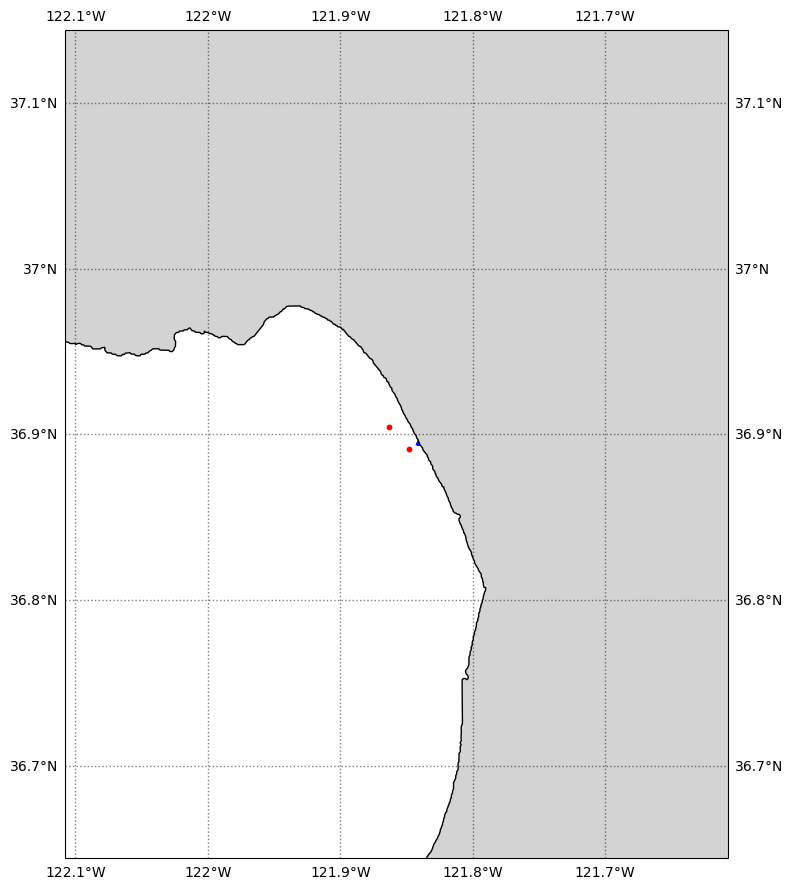

In [84]:
projection = 'platecarree'

fig = plt.figure(figsize=(9,9))
plt.clf()

tformM = ccrs.Mollweide()
tformP = ccrs.PlateCarree()

if projection == 'mollweide':
    tform = tformM
elif projection == 'platecarree':
    tform = tformP

ax = plt.axes(projection=tform)

# Points
wp.plot(ax=ax, marker='o', color='red', markersize=10, transform=tform)
closest_point_gdf.plot(ax=ax, marker='^', color='b', markersize=10, transform=tform)


# Use the full resolution GSHHS data
land = GSHHSFeature(scale='f', levels=[1])  # 'f' is for full resolution
ax.add_feature(land, facecolor='lightgray')


gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, 
    color='black', alpha=0.5, linestyle=':', draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = True
gl.ylabels_right=False
gl.xlines = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'color': 'black'}# 'weight': 'bold'}
gl.ylabel_style = {'color': 'black'}# 'weight': 'bold'}
#gl.xlocator = mticker.FixedLocator([-180., -160, -140, -120, -60, -20.])
#gl.xlocator = mticker.FixedLocator([-240., -180., -120, -65, -60, -55, 0, 60, 120.])
#gl.ylocator = mticker.FixedLocator([0., 15., 30., 45, 60.])

# Limits
ax.set_xlim(lon_lim)
ax.set_ylim(lat_lim)

# Finish
plt.tight_layout()
plt.show()